# Lab 7 – Bagging, Boosting and Stacking Classification Models
Build Bagging, Boosting and Stacking classification models and evaluate their performance using appropriate metrics.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

In [2]:
ckd = fetch_ucirepo(id=336)

X = ckd.data.features
y = ckd.data.targets

df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [3]:
# Replace '?' with NaN and handle missing values
df.replace('?', np.nan, inplace=True)

num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
cat_cols = [col for col in df.columns if col not in num_cols + ['class']]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df['class'] = df['class'].str.strip().map({'ckd': 0, 'notckd': 1})

print("Shape:", df.shape)
print("Class distribution:\n", df['class'].value_counts())
df.head()

Shape: (400, 25)
Class distribution:
 class
0    250
1    150
Name: count, dtype: int64


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,3,1,0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,2,0,0,0,0,0
1,7.0,50.0,3,4,0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,1,0,0,0,0,0
2,62.0,80.0,1,2,3,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,2,0,1,0,1,0
3,48.0,70.0,0,4,0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,1,0,1,1,1,0
4,51.0,80.0,1,2,0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,1,0,0,0,0,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_feat = df.drop('class', axis=1)
y_target = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_target, test_size=0.2, random_state=42, stratify=y_target
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Training set:", X_train_sc.shape)
print("Test set:    ", X_test_sc.shape)

Training set: (320, 24)
Test set:     (80, 24)


---
## Part A – Bagging (Bootstrap Aggregating)
Bagging reduces variance by training multiple base learners on bootstrapped subsets and aggregating predictions.

In [5]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# Bagging with Decision Tree base estimator
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)
bag_model.fit(X_train_sc, y_train)
y_bag_pred = bag_model.predict(X_test_sc)

# Random Forest (popular Bagging variant)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sc, y_train)
y_rf_pred = rf_model.predict(X_test_sc)

print("=== Bagging (Decision Tree) ===")
print(f"Accuracy : {accuracy_score(y_test, y_bag_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_bag_pred, average='weighted'):.4f}")

print("\n=== Random Forest (Bagging Variant) ===")
print(f"Accuracy : {accuracy_score(y_test, y_rf_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_rf_pred, average='weighted'):.4f}")

=== Bagging (Decision Tree) ===
Accuracy : 0.9625
F1 Score : 0.9621

=== Random Forest (Bagging Variant) ===
Accuracy : 0.9750
F1 Score : 0.9748


=== Bagging – Classification Report ===
              precision    recall  f1-score   support

         CKD       0.94      1.00      0.97        50
     Not CKD       1.00      0.90      0.95        30

    accuracy                           0.96        80
   macro avg       0.97      0.95      0.96        80
weighted avg       0.96      0.96      0.96        80



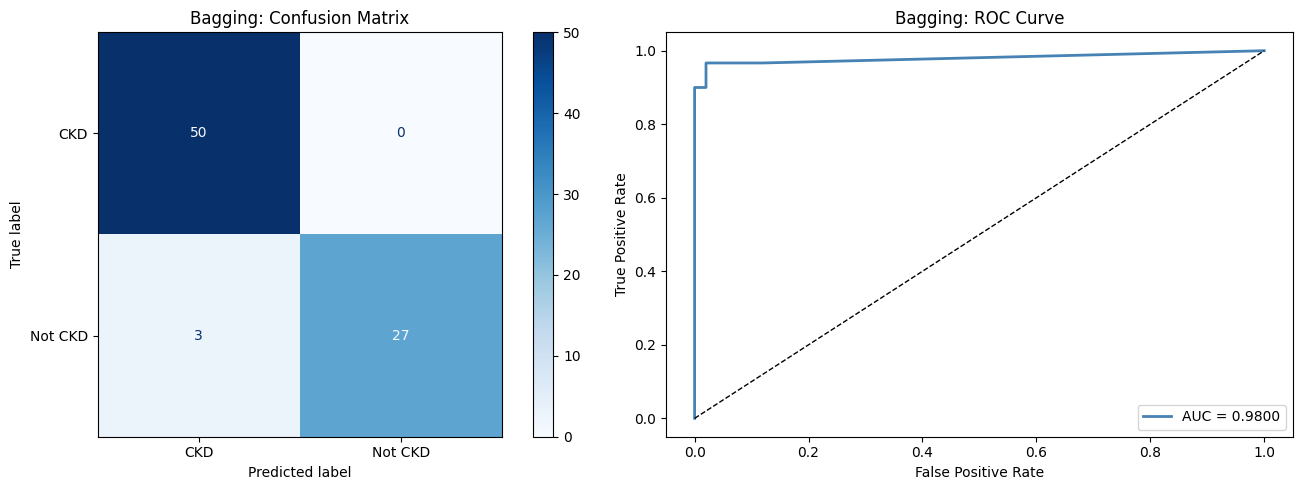

In [6]:
print("=== Bagging – Classification Report ===")
print(classification_report(y_test, y_bag_pred, target_names=['CKD', 'Not CKD']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_bag_pred), display_labels=['CKD', 'Not CKD']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Bagging: Confusion Matrix')

y_bag_prob = bag_model.predict_proba(X_test_sc)[:, 1]
fpr_bag, tpr_bag, _ = roc_curve(y_test, y_bag_prob)
roc_auc_bag = auc(fpr_bag, tpr_bag)
axes[1].plot(fpr_bag, tpr_bag, color='steelblue', lw=2, label=f'AUC = {roc_auc_bag:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Bagging: ROC Curve')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

C:\Users\Akhilesh Bhute\AppData\Local\Temp\ipykernel_34252\161513148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


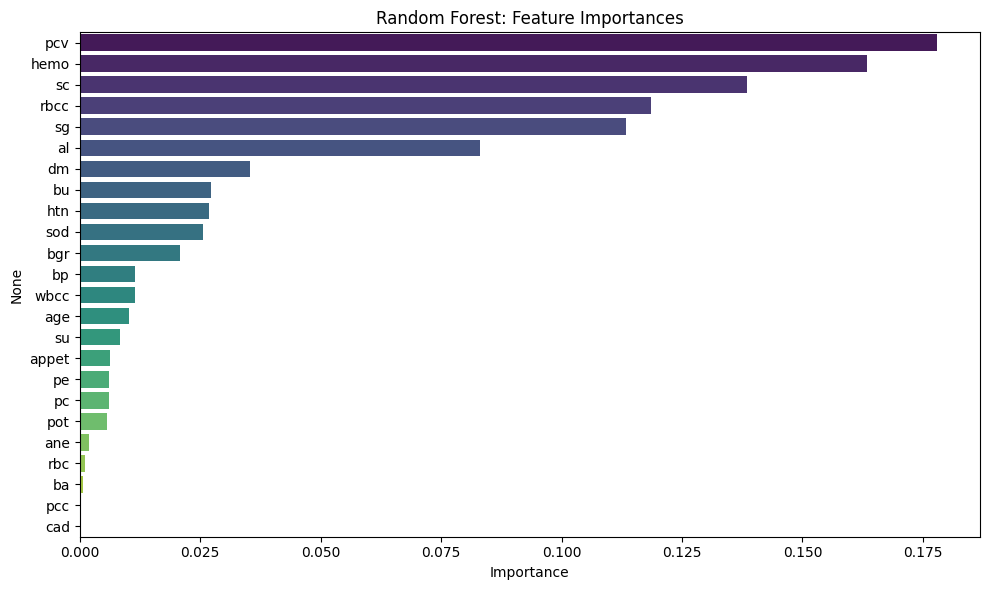

In [7]:
# Feature importance from Random Forest
feat_imp = pd.Series(rf_model.feature_importances_, index=X_feat.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Random Forest: Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## Part B – Boosting
Boosting builds models sequentially, each correcting the errors of the previous one.

In [8]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# AdaBoost
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada_model.fit(X_train_sc, y_train)
y_ada_pred = ada_model.predict(X_test_sc)

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_sc, y_train)
y_gb_pred = gb_model.predict(X_test_sc)

print("=== AdaBoost ===")
print(f"Accuracy : {accuracy_score(y_test, y_ada_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_ada_pred, average='weighted'):.4f}")

print("\n=== Gradient Boosting ===")
print(f"Accuracy : {accuracy_score(y_test, y_gb_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_gb_pred, average='weighted'):.4f}")

=== AdaBoost ===
Accuracy : 1.0000
F1 Score : 1.0000

=== Gradient Boosting ===
Accuracy : 0.9750
F1 Score : 0.9748


=== AdaBoost – Classification Report ===
              precision    recall  f1-score   support

         CKD       1.00      1.00      1.00        50
     Not CKD       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



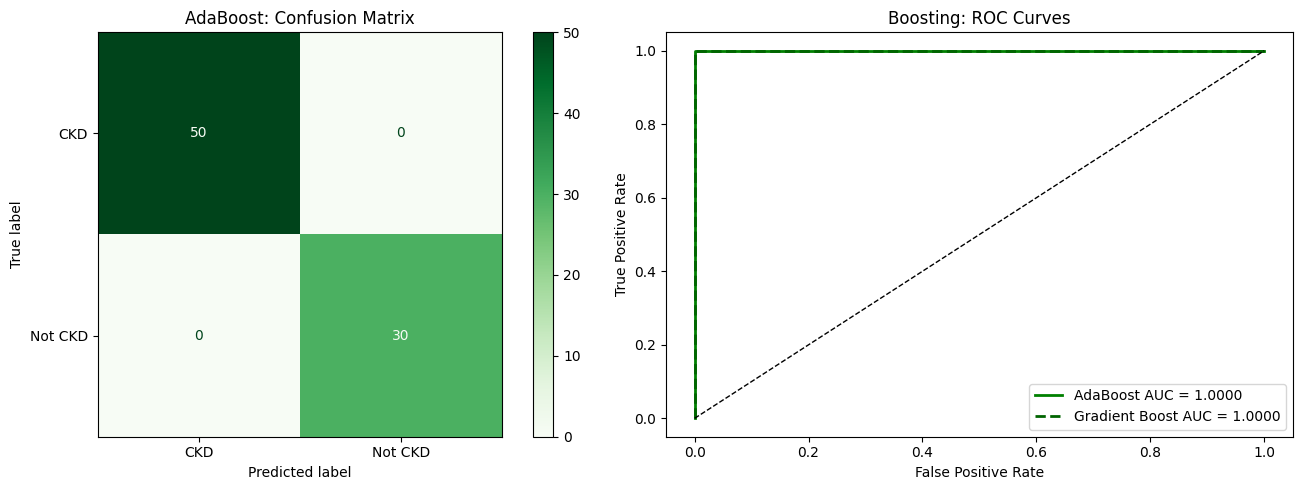

In [9]:
print("=== AdaBoost – Classification Report ===")
print(classification_report(y_test, y_ada_pred, target_names=['CKD', 'Not CKD']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_ada_pred), display_labels=['CKD', 'Not CKD']).plot(ax=axes[0], cmap='Greens')
axes[0].set_title('AdaBoost: Confusion Matrix')

y_ada_prob = ada_model.predict_proba(X_test_sc)[:, 1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_ada_prob)
roc_auc_ada = auc(fpr_ada, tpr_ada)
axes[1].plot(fpr_ada, tpr_ada, color='green', lw=2, label=f'AdaBoost AUC = {roc_auc_ada:.4f}')

y_gb_prob = gb_model.predict_proba(X_test_sc)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_gb_prob)
roc_auc_gb = auc(fpr_gb, tpr_gb)
axes[1].plot(fpr_gb, tpr_gb, color='darkgreen', lw=2, linestyle='--', label=f'Gradient Boost AUC = {roc_auc_gb:.4f}')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Boosting: ROC Curves')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Part C – Stacking
Stacking trains multiple diverse base learners and uses a meta-learner to combine their predictions.

In [10]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Base learners
base_estimators = [
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
]

# Meta-learner
stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    passthrough=False
)
stack_model.fit(X_train_sc, y_train)
y_stack_pred = stack_model.predict(X_test_sc)

print("=== Stacking – Evaluation Metrics ===")
print(f"Accuracy  : {accuracy_score(y_test, y_stack_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_stack_pred, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_stack_pred, average='weighted'):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_stack_pred, average='weighted'):.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_stack_pred, target_names=['CKD', 'Not CKD']))

=== Stacking – Evaluation Metrics ===
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000

=== Classification Report ===
              precision    recall  f1-score   support

         CKD       1.00      1.00      1.00        50
     Not CKD       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



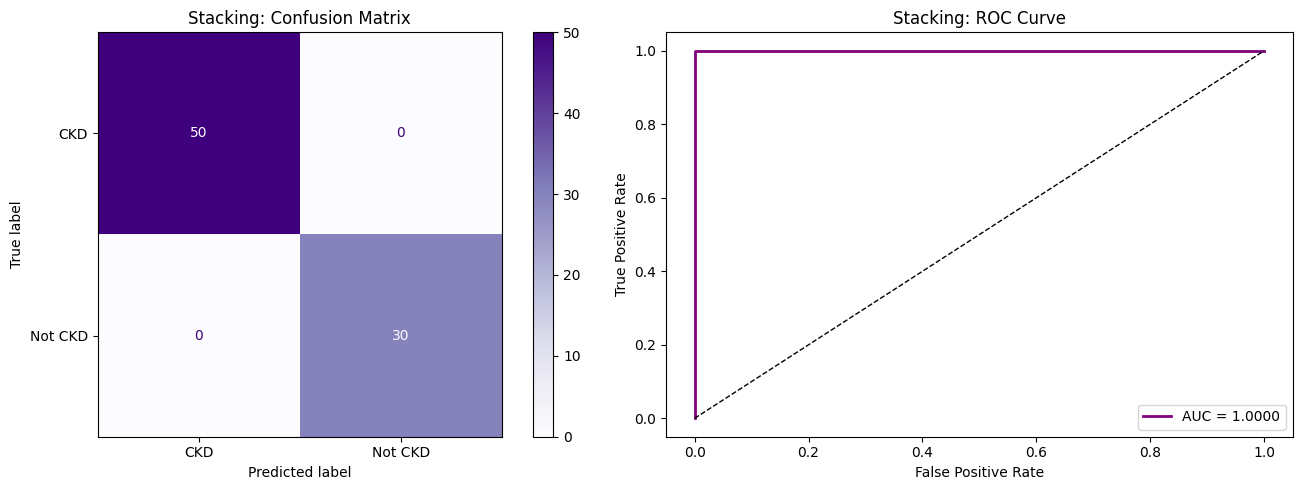

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_stack_pred), display_labels=['CKD', 'Not CKD']).plot(ax=axes[0], cmap='Purples')
axes[0].set_title('Stacking: Confusion Matrix')

y_stack_prob = stack_model.predict_proba(X_test_sc)[:, 1]
fpr_st, tpr_st, _ = roc_curve(y_test, y_stack_prob)
roc_auc_st = auc(fpr_st, tpr_st)
axes[1].plot(fpr_st, tpr_st, color='purple', lw=2, label=f'AUC = {roc_auc_st:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Stacking: ROC Curve')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Overall Model Comparison

                   Accuracy  Precision  Recall  F1 Score   ROC AUC
Model                                                             
Bagging (DT)         0.9625   0.964623  0.9625  0.962059  0.980000
Random Forest        0.9750   0.975962  0.9750  0.974814  0.999333
AdaBoost             1.0000   1.000000  1.0000  1.000000  1.000000
Gradient Boosting    0.9750   0.975962  0.9750  0.974814  1.000000
Stacking             1.0000   1.000000  1.0000  1.000000  1.000000


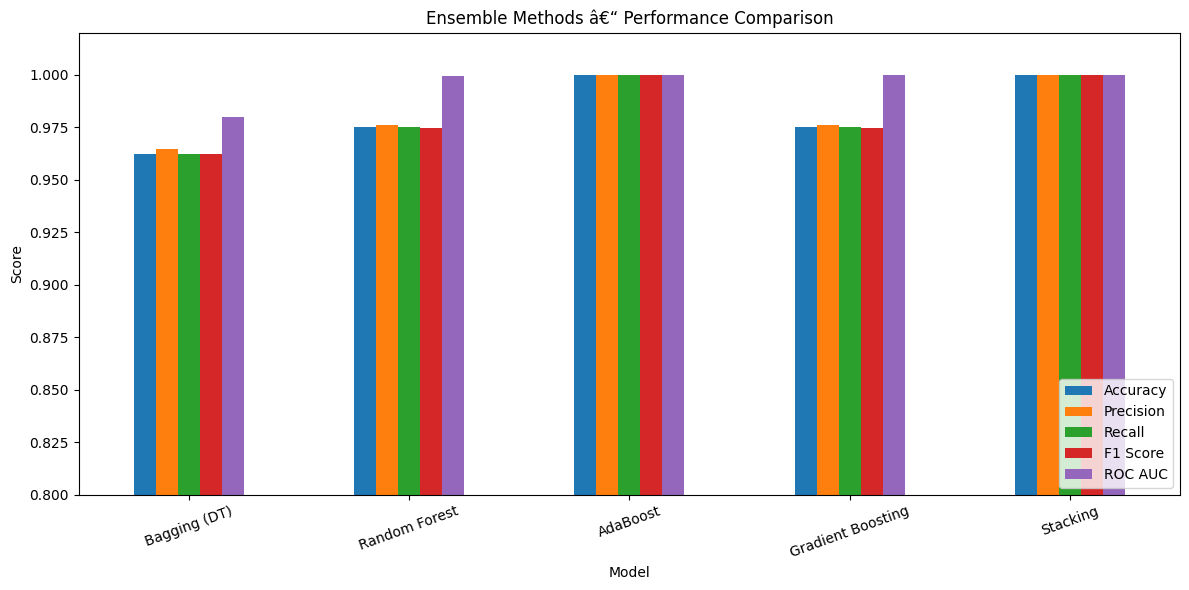

In [12]:
models = {
    'Bagging (DT)':        (y_bag_pred,   bag_model.predict_proba(X_test_sc)[:, 1]),
    'Random Forest':       (y_rf_pred,    rf_model.predict_proba(X_test_sc)[:, 1]),
    'AdaBoost':            (y_ada_pred,   ada_model.predict_proba(X_test_sc)[:, 1]),
    'Gradient Boosting':   (y_gb_pred,    gb_model.predict_proba(X_test_sc)[:, 1]),
    'Stacking':            (y_stack_pred, stack_model.predict_proba(X_test_sc)[:, 1]),
}

rows = []
for name, (pred, prob) in models.items():
    fpr_, tpr_, _ = roc_curve(y_test, prob)
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall':    recall_score(y_test, pred, average='weighted'),
        'F1 Score':  f1_score(y_test, pred, average='weighted'),
        'ROC AUC':   auc(fpr_, tpr_)
    })

comparison = pd.DataFrame(rows).set_index('Model')
print(comparison.to_string())

comparison.plot(kind='bar', figsize=(12, 6), ylim=(0.8, 1.02), rot=20)
plt.title('Ensemble Methods – Performance Comparison')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()